In [1]:
!pip install -q git+https://github.com/huggingface/transformers
!pip install -q accelerate qwen-vl-utils==0.0.14
!pip install -q rapidfuzz editdistance jiwer

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.4/35.4 MB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 104.7 MB/s eta 0:00:00


In [5]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [6]:
import os
import re
import json
import time

import torch
import pandas as pd

from PIL import Image
from tqdm import tqdm

from transformers import (
    Qwen3VLForConditionalGeneration,
    AutoProcessor,
)


In [14]:
IMAGE_DIR   = "/content/drive/MyDrive/Ingredients_200/Images"
GROUND_CSV  = "/content/drive/MyDrive/Ingredients_200/ground.csv"

PRED_DIR    = "/content/drive/MyDrive/Ingredients_200_Results/qwen3vl_outputs"
RESULTS_CSV = "/content/drive/MyDrive/Ingredients_200_Results/qwen3vl_results.csv"
CHECKPOINT  = "/content/drive/MyDrive/Ingredients_200_Results/checkpoint.json"

os.makedirs(PRED_DIR, exist_ok=True)

In [9]:
MODEL_NAME = "Qwen/Qwen3-VL-2B-Instruct"

PROMPT = """You are an information extraction system.

Task:
Extract all ingredients visible on this product package.

Rules:
1. Return only ingredients.
2. Ignore warnings, allergy info, directions, storage and manufacturer details.
3. Return valid JSON only — no markdown, no explanation.

Output format:
{
  "ingredients": ["ingredient 1", "ingredient 2"]
}"""

print("config ready")
print("image dir :", IMAGE_DIR)
print("output dir:", PRED_DIR)

config ready
image dir : /content/drive/MyDrive/Ingredients_200/Images
output dir: /content/drive/MyDrive/Ingredients_200_Results/qwen3vl_outputs


In [10]:
import torch
from transformers import AutoProcessor, Qwen3VLForConditionalGeneration

print("Loading processor...")

# Limit visual tokens to reduce GPU memory usage
processor = AutoProcessor.from_pretrained(
    MODEL_NAME,
    max_pixels=768 * 28 * 28,
)

print("Loading model...")

model = Qwen3VLForConditionalGeneration.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,   # Better than bf16 on T4
    device_map="auto",
)

model.eval()

print("Model loaded on:", next(model.parameters()).device)

Loading processor...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/390 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/5.50k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.50k [00:00<?, ?B/s]

...

Loading model...


model.safetensors:   0%|          | 0.00/4.26G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/269 [00:00<?, ?B/s]

Model loaded on: cuda:0


In [11]:
def extract_json(response):

    response = response.strip()
    response = response.replace("```json", "").replace("```", "").strip()

    start = response.find("{")
    end   = response.rfind("}")

    if start == -1 or end == -1:
        return {"ingredients": []}

    json_text = response[start : end + 1]

    try:
        data = json.loads(json_text)
        if "ingredients" not in data:
            data["ingredients"] = []
        return data
    except Exception:
        print("\nFAILED TO PARSE JSON\n", json_text[:200])
        return {"ingredients": []}

In [15]:
if os.path.exists(CHECKPOINT):
    with open(CHECKPOINT) as f:
        done = set(json.load(f))
    print(f"resuming — {len(done)} images already done")
else:
    done = set()

image_files = sorted([
    f for f in os.listdir(IMAGE_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
])

results = []

for image_name in tqdm(image_files, desc="inference"):

    # skip already processed
    if image_name in done:
        continue

    image_path = os.path.join(IMAGE_DIR, image_name)
    image      = Image.open(image_path).convert("RGB")

    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text",  "text": PROMPT},
            ],
        }
    ]

    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    inputs = processor(
        text=[text],
        images=[image],
        return_tensors="pt",
    ).to(model.device)

    start_t = time.time()

    generated_ids = model.generate(
        **inputs,
        max_new_tokens=512,
        do_sample=False,
    )

    runtime = time.time() - start_t

    generated_ids = generated_ids[:, inputs.input_ids.shape[1]:]

    response = processor.batch_decode(
        generated_ids,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    )[0]

    pred = extract_json(response)
    pred["runtime_sec"] = runtime

    # write per-image json
    base = os.path.splitext(image_name)[0]
    with open(os.path.join(PRED_DIR, base + ".json"), "w") as f:
        json.dump(pred, f, indent=4)

    results.append({
        "image":           image_name,
        "num_ingredients": len(pred.get("ingredients", [])),
        "runtime_sec":     runtime,
    })

    done.add(image_name)

    # checkpoint every 10 images
    if len(done) % 10 == 0:
        with open(CHECKPOINT, "w") as f:
            json.dump(list(done), f)

# final checkpoint save
with open(CHECKPOINT, "w") as f:
    json.dump(list(done), f)

# save results csv
pd.DataFrame(results).to_csv(RESULTS_CSV, index=False)

print("\nDONE")
print("images processed :", len(results))
print("avg runtime (s)  :", round(sum(r["runtime_sec"] for r in results) / max(len(results), 1), 2))
print("avg ingredients  :", round(sum(r["num_ingredients"] for r in results) / max(len(results), 1), 2))


inference: 100%|██████████| 187/187 [24:41<00:00,  7.92s/it]


DONE
images processed : 187
avg runtime (s)  : 7.83
avg ingredients  : 7.59


In [16]:
import editdistance
from rapidfuzz import fuzz
from jiwer import wer

EVAL_DIR        = "/content/drive/MyDrive/Ingredients_200_Results/evaluation"
PER_IMAGE_CSV   = os.path.join(EVAL_DIR, "per_image_results.csv")
SUMMARY_JSON    = os.path.join(EVAL_DIR, "summary.json")

os.makedirs(EVAL_DIR, exist_ok=True)


def normalize(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9 ]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def token_metrics(gt_text, pred_text):
    gt_tokens   = set(gt_text.split())
    pred_tokens = set(pred_text.split())

    tp = len(gt_tokens & pred_tokens)
    fp = len(pred_tokens - gt_tokens)
    fn = len(gt_tokens - pred_tokens)

    precision = tp / (tp + fp + 1e-8)
    recall    = tp / (tp + fn + 1e-8)
    f1        = 2 * precision * recall / (precision + recall + 1e-8)
    jaccard   = tp / (tp + fp + fn + 1e-8)

    return precision, recall, f1, jaccard


def compute_cer(gt, pred):
    if len(gt) == 0:
        return 1.0
    return editdistance.eval(gt, pred) / len(gt)


print("evaluation helpers ready")

evaluation helpers ready


In [17]:
gt_df = pd.read_csv(GROUND_CSV)

# normalise column names in case of whitespace
gt_df.columns = [c.strip().lower() for c in gt_df.columns]

# detect column names flexibly
img_col = [c for c in gt_df.columns if "image" in c or "name" in c or "file" in c][0]
ing_col = [c for c in gt_df.columns if "ingr" in c][0]

eval_results = []

for _, row in tqdm(gt_df.iterrows(), total=len(gt_df), desc="evaluation"):

    image_name = str(row[img_col]).strip()
    gt_text    = normalize(row[ing_col])

    base      = os.path.splitext(image_name)[0]
    pred_file = os.path.join(PRED_DIR, base + ".json")

    if not os.path.exists(pred_file):
        continue

    with open(pred_file, "r", encoding="utf-8") as f:
        pred_data = json.load(f)

    pred_list = pred_data.get("ingredients", [])
    pred_text = normalize(", ".join(pred_list))

    wer_score   = wer(gt_text, pred_text if pred_text else "none")
    cer_score   = compute_cer(gt_text, pred_text)
    fuzzy_score = fuzz.ratio(gt_text, pred_text)

    precision, recall, f1, jaccard = token_metrics(gt_text, pred_text)

    eval_results.append({
        "image":     image_name,
        "wer":       wer_score,
        "cer":       cer_score,
        "fuzzy":     fuzzy_score,
        "precision": precision,
        "recall":    recall,
        "f1":        f1,
        "jaccard":   jaccard,
    })

results_df = pd.DataFrame(eval_results)
results_df.to_csv(PER_IMAGE_CSV, index=False)

summary = {
    "num_images":    len(results_df),
    "avg_wer":       float(results_df["wer"].mean()),
    "avg_cer":       float(results_df["cer"].mean()),
    "avg_fuzzy":     float(results_df["fuzzy"].mean()),
    "avg_precision": float(results_df["precision"].mean()),
    "avg_recall":    float(results_df["recall"].mean()),
    "avg_f1":        float(results_df["f1"].mean()),
    "avg_jaccard":   float(results_df["jaccard"].mean()),
}

with open(SUMMARY_JSON, "w") as f:
    json.dump(summary, f, indent=4)

print("\n===== RESULTS =====\n")
print(json.dumps(summary, indent=4))


evaluation: 100%|██████████| 187/187 [00:00<00:00, 235.47it/s]


===== RESULTS =====

{
    "num_images": 187,
    "avg_wer": 0.9285552702281937,
    "avg_cer": 0.8054610818512002,
    "avg_fuzzy": 69.35472399256399,
    "avg_precision": 0.5975090497114715,
    "avg_recall": 0.7102111252585118,
    "avg_f1": 0.6162698601658627,
    "avg_jaccard": 0.49664406495006325
}


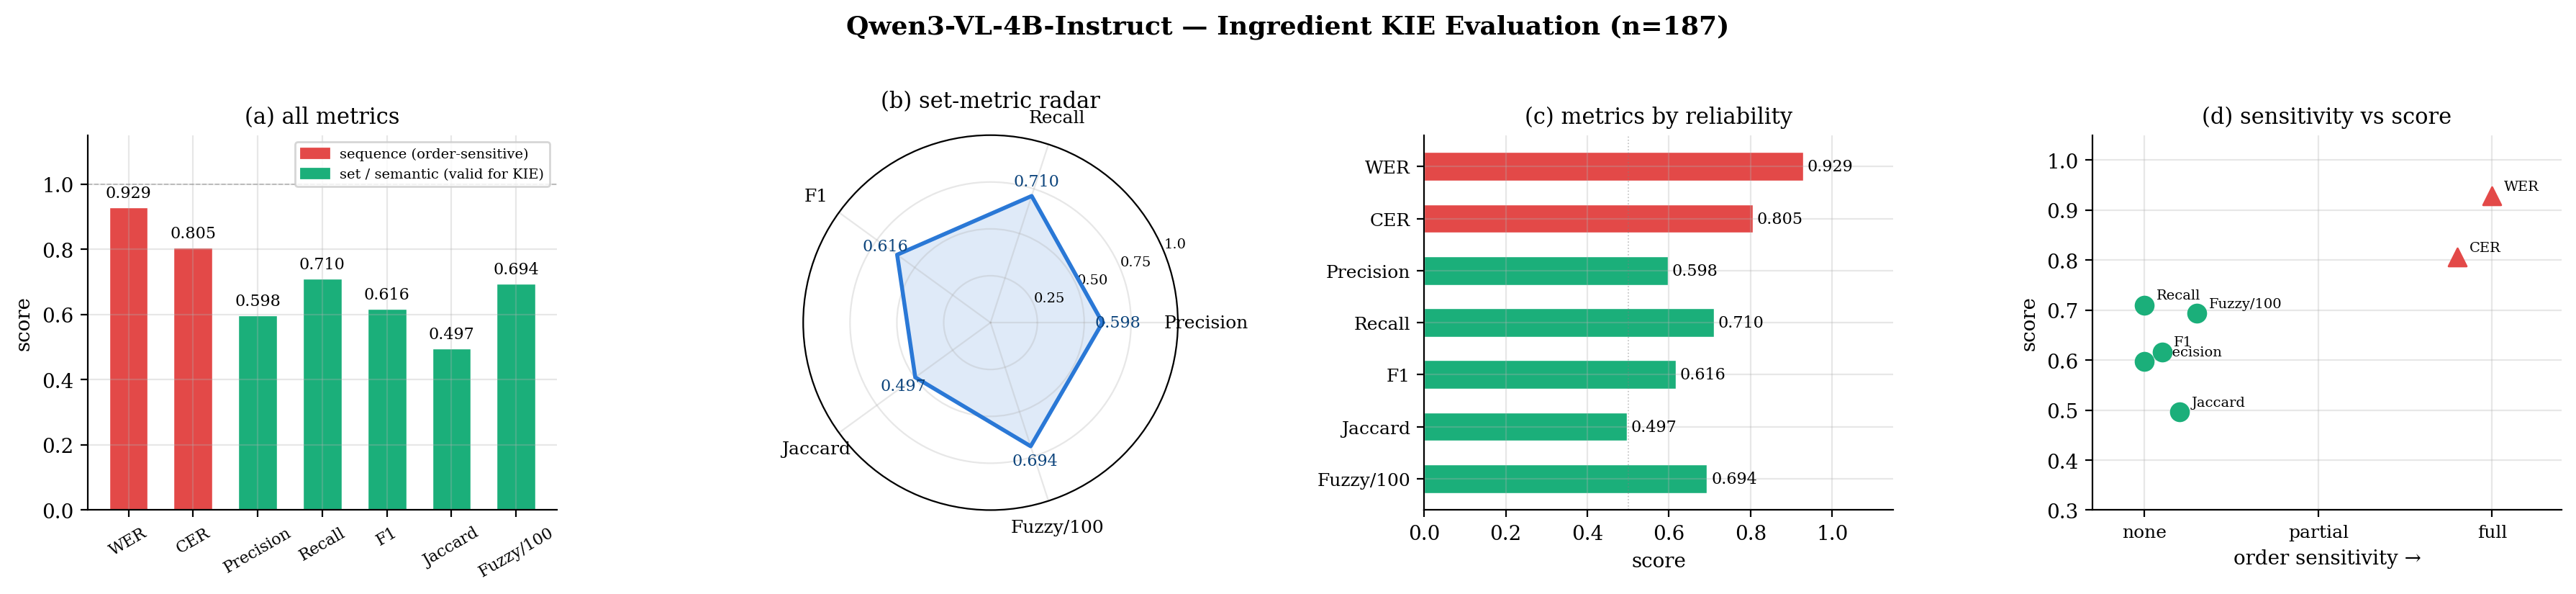

saved → kie_evaluation_figures.pdf / .png


In [18]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

METRICS = {
    "WER":       0.9286,
    "CER":       0.8055,
    "Precision": 0.5975,
    "Recall":    0.7102,
    "F1":        0.6163,
    "Jaccard":   0.4966,
    "Fuzzy/100": 0.6935,
}

SEQ_METRICS  = ["WER", "CER"]
SET_METRICS  = ["Precision", "Recall", "F1", "Jaccard", "Fuzzy/100"]
COLOR_SEQ    = "#e34948"
COLOR_SET    = "#1baf7a"

plt.rcParams.update({
    "font.family"    : "serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid"      : True,
    "grid.alpha"     : 0.3,
    "figure.dpi"     : 200,
})

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle(
    "Qwen3-VL-4B-Instruct — Ingredient KIE Evaluation (n=187)",
    fontsize=13, fontweight="bold", y=1.02,
)


# ── figure 1: full metric bar chart ─────────────────────────────────────────

ax = axes[0]
labels = list(METRICS.keys())
values = list(METRICS.values())
colors = [COLOR_SEQ if l in SEQ_METRICS else COLOR_SET for l in labels]
bars = ax.bar(labels, values, color=colors, edgecolor="white", linewidth=0.5,
              width=0.6)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{val:.3f}", ha="center", va="bottom", fontsize=8)
ax.set_ylim(0, 1.15)
ax.set_ylabel("score", fontsize=10)
ax.set_title("(a) all metrics", fontsize=11)
ax.tick_params(axis="x", labelsize=8, rotation=30)
ax.axhline(1.0, color="gray", linewidth=0.6, linestyle="--", alpha=0.5)
patch_seq = mpatches.Patch(color=COLOR_SEQ, label="sequence (order-sensitive)")
patch_set = mpatches.Patch(color=COLOR_SET, label="set / semantic (valid for KIE)")
ax.legend(handles=[patch_seq, patch_set], fontsize=7, loc="upper right")


# ── figure 2: radar chart (set metrics only) ────────────────────────────────

ax2 = axes[1]
radar_labels = ["Precision", "Recall", "F1", "Jaccard", "Fuzzy/100"]
radar_values = [METRICS[k] for k in radar_labels]
N = len(radar_labels)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]
vals = radar_values + radar_values[:1]

ax_r = fig.add_subplot(1, 4, 2, polar=True)
axes[1].set_visible(False)

ax_r.plot(angles, vals, color="#2a78d6", linewidth=2)
ax_r.fill(angles, vals, color="#2a78d6", alpha=0.15)
ax_r.set_xticks(angles[:-1])
ax_r.set_xticklabels(radar_labels, size=9)
ax_r.set_ylim(0, 1)
ax_r.set_yticks([0.25, 0.5, 0.75, 1.0])
ax_r.set_yticklabels(["0.25", "0.50", "0.75", "1.0"], size=7)
ax_r.set_title("(b) set-metric radar", fontsize=11, pad=14)
for angle, val, lbl in zip(angles[:-1], radar_values, radar_labels):
    ax_r.text(angle, val + 0.08, f"{val:.3f}", ha="center", va="center",
              fontsize=8, color="#0c447c")


# ── figure 3: horizontal bar sorted by validity ──────────────────────────────

ax = axes[2]
sorted_labels = SEQ_METRICS + SET_METRICS
sorted_values = [METRICS[k] for k in sorted_labels]
sorted_colors = [COLOR_SEQ] * 2 + [COLOR_SET] * 5
y_pos = range(len(sorted_labels))
ax.barh(list(y_pos), sorted_values, color=sorted_colors,
        edgecolor="white", linewidth=0.5, height=0.55)
ax.set_yticks(list(y_pos))
ax.set_yticklabels(sorted_labels, fontsize=9)
for i, (v, c) in enumerate(zip(sorted_values, sorted_colors)):
    ax.text(v + 0.01, i, f"{v:.3f}", va="center", fontsize=8)
ax.set_xlim(0, 1.15)
ax.set_xlabel("score", fontsize=10)
ax.set_title("(c) metrics by reliability", fontsize=11)
ax.axvline(0.5, color="gray", linewidth=0.6, linestyle=":", alpha=0.5)
ax.invert_yaxis()


# ── figure 4: scatter — order sensitivity vs score ───────────────────────────

ax = axes[3]
sensitivity = {
    "WER": 1.0, "CER": 0.9,
    "Precision": 0.0, "Recall": 0.0, "F1": 0.05,
    "Jaccard": 0.1, "Fuzzy/100": 0.15,
}
for name, val in METRICS.items():
    s   = sensitivity[name]
    col = COLOR_SEQ if name in SEQ_METRICS else COLOR_SET
    mk  = "^" if name in SEQ_METRICS else "o"
    ax.scatter(s, val, color=col, marker=mk, s=80, zorder=3)
    ax.annotate(name, (s, val),
                textcoords="offset points", xytext=(6, 3), fontsize=7)
ax.set_xlabel("order sensitivity →", fontsize=10)
ax.set_ylabel("score", fontsize=10)
ax.set_title("(d) sensitivity vs score", fontsize=11)
ax.set_xlim(-0.15, 1.2)
ax.set_ylim(0.3, 1.05)
ax.set_xticks([0, 0.5, 1.0])
ax.set_xticklabels(["none", "partial", "full"], fontsize=9)

plt.tight_layout()
plt.savefig("kie_evaluation_figures.pdf", bbox_inches="tight")
plt.savefig("kie_evaluation_figures.png", dpi=200, bbox_inches="tight")
plt.show()
print("saved → kie_evaluation_figures.pdf / .png")